In [1]:
# ============================================================
# 1. IMPORT E SETUP
# ============================================================
import sys
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict

# Configurazione del percorso radice del progetto
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

# Import delle classi dal tuo codice di progetto
from src.models.baseline import EmbeddingNet
from src.utils.GradCAM import show_gradcam, GradCAMPlusPlus

In [2]:
# ============================================================
# 2. CARICAMENTO MODELLO
# ============================================================
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = os.path.join(BASE_DIR, "experiments", "checkpoints", "baseline10.pth")

# Inizializzazione della rete
model = EmbeddingNet(dim=128, pretrained=True).to(device)
state_dict = torch.load(ckpt_path, map_location=device)

if isinstance(state_dict, dict) and "model_state_dict" in state_dict:
    model.load_state_dict(state_dict["model_state_dict"])
else:
    model.load_state_dict(state_dict)

model.eval()
print(f"Modello caricato con successo da: {ckpt_path}")

# Definizione del penultimo layer convoluzionale dell'encoder per Grad-CAM
target_layer = model.encoder[-2]

Modello caricato con successo da: p:\Uni\mujoco\dl26-projects\experiments\checkpoints\baseline10.pth


In [6]:
# ============================================================
# 3. METADATI E PREPROCESSO IMAGINI
# ============================================================
IMAGE_DIR = os.path.join(BASE_DIR, "data", "images") # Modifica con il tuo percorso reale delle immagini

# Caricamento del file CSV contenente i metadati di validazione/test
df_train = pd.read_csv(os.path.join(BASE_DIR, "data", "df_train.csv")) 

# Dizionario facoltativo per mappare gli ID numerici delle classi nei loro nomi testuali
all_labels = df_train["labels"].unique()
label2idx  = {l: i for i, l in enumerate(all_labels)}
idx2label  = {i: l for l, i in label2idx.items()}

# Trasformazione standard coerente con i vincoli del modello
transform_model = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

In [14]:
def calculate_class_prototypes(model, df, image_dir, transform, device, label2idx):
    """
    Estrae gli embedding di tutte le immagini nel dataset e calcola 
    il vettore medio (prototipo) per ciascuna classe presente.
    """
    model.eval()
    embeddings_by_class = defaultdict(list)
    
    print("Estrazione degli embedding in corso...")
    
    with torch.no_grad():
        for idx, row in df.iterrows():
            img_id = row['image_id']
            
            # RECUPERO ID NUMERICO: Usa il testo della riga per ottenere l'indice intero
            label_text = row['labels']
            label = label2idx[label_text] 
            
            img_path = os.path.join(image_dir, f"{img_id}.jpg")
            
            if os.path.exists(img_path):
                img_pil = Image.open(img_path).convert("RGB")
                x = transform(img_pil).unsqueeze(0).to(device)
                
                embedding = model(x) 
                embeddings_by_class[label].append(embedding.cpu())
                
    # Calcolo del prototipo medio per ogni classe
    prototypes = {}
    for label, embs in embeddings_by_class.items():
        all_embs_tensor = torch.cat(embs, dim=0)    
        mean_embedding  = all_embs_tensor.mean(dim=0) 
        prototypes[label] = mean_embedding.to(device)
        
    print(f"Calcolo completato! Generati i prototipi per {len(prototypes)} classi.")
    return prototypes

In [16]:
prototypes = calculate_class_prototypes(model, df_train, IMAGE_DIR, transform_model, device, label2idx)

Estrazione degli embedding in corso...
Calcolo completato! Generati i prototipi per 14 classi.


In [17]:
#============================================================
# Embeddings + retrieval
#============================================================
from src.datasets.datasets import SceneDataset
from src.evaluation.retrieval import compute_embeddings, evaluate_retrieval, print_metrics

transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

df_val = pd.read_csv(os.path.join(BASE_DIR, "data", "df_val.csv"))

dataset_val = SceneDataset(
    df_val,
    IMAGE_DIR,
    label2idx=label2idx,
    transform=transform_eval,
)

embeddings, labels = compute_embeddings(
    model=model,
    dataset=dataset_val,
    device=device,
    batch_size=64,
    num_workers=0,
    normalize=True,
)

results, indices, scores = evaluate_retrieval(embeddings, labels, ks=(1, 5, 10))
print_metrics(results)



========== Retrieval Metrics ==========

acc@1               : 0.6209
precision_macro     : 0.5892
recall_macro        : 0.5712
recall@1            : 0.6209
recall@5            : 0.8351
recall@10           : 0.8840
precision@1         : 0.6209
precision@5         : 0.6197
precision@10        : 0.6175
mrr                 : 0.7148
map                 : 0.6786



In [18]:
# ============================================================
# 5. SELEZIONE CASI DI RETRIEVAL ERRATI (MISS)
# ============================================================

# Trova i primi 3 casi in cui il primo elemento recuperato (Top-1) ha una classe sbagliata
miss_queries = []
for i in range(len(df_val)):
    if int(labels[indices[i][1]]) != int(labels[i]):
        miss_queries.append(i)
    if len(miss_queries) == 3:
        break

print(f"Trovati {len(miss_queries)} casi MISS da analizzare.")

Trovati 3 casi MISS da analizzare.



--- Analisi Grad-CAM per la Query errore con Indice: 1 ---


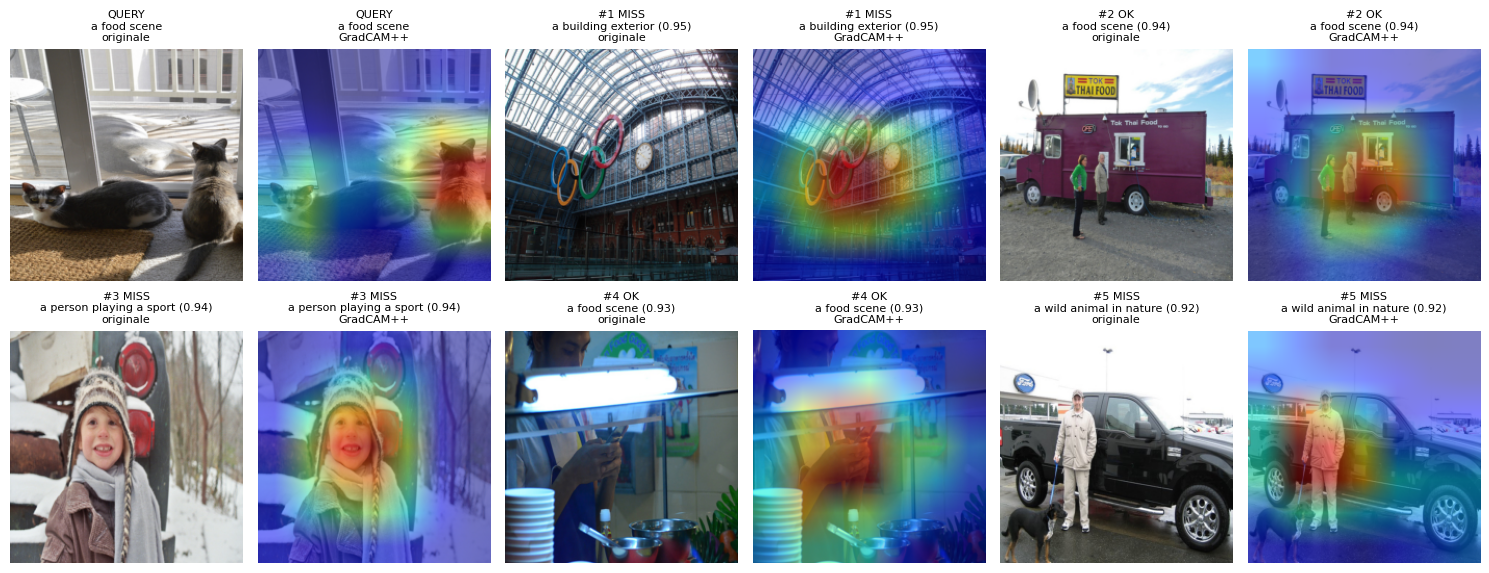


--- Analisi Grad-CAM per la Query errore con Indice: 2 ---


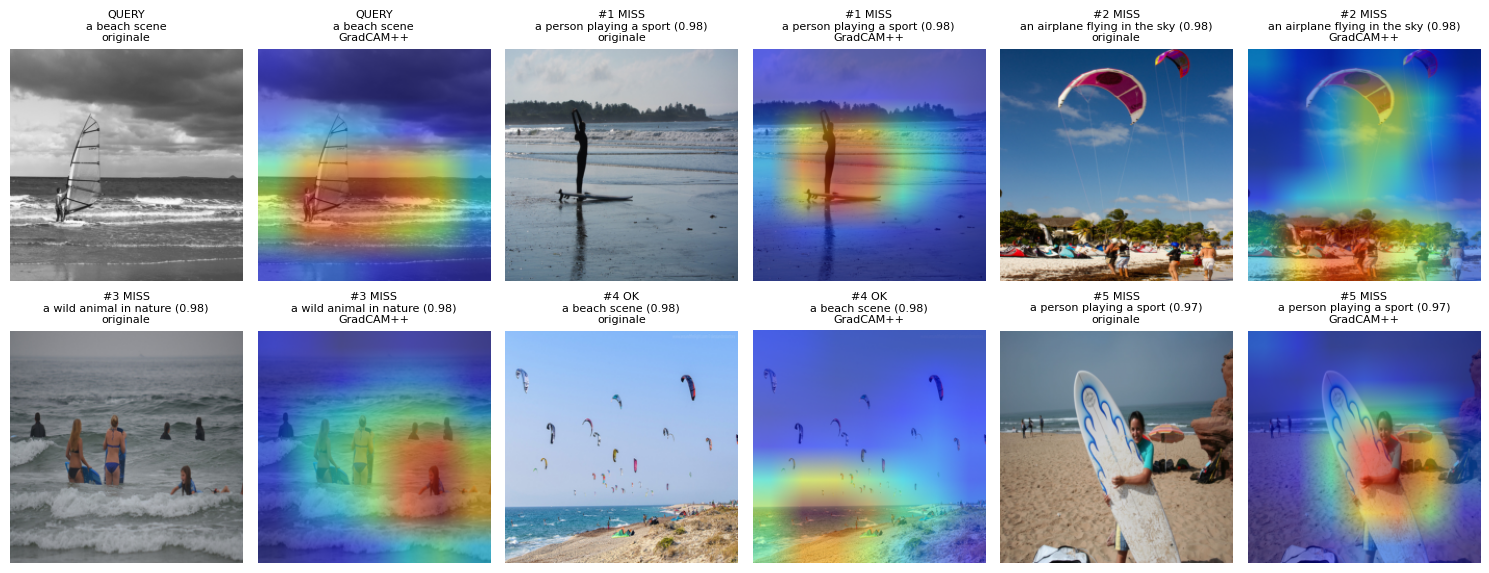


--- Analisi Grad-CAM per la Query errore con Indice: 3 ---


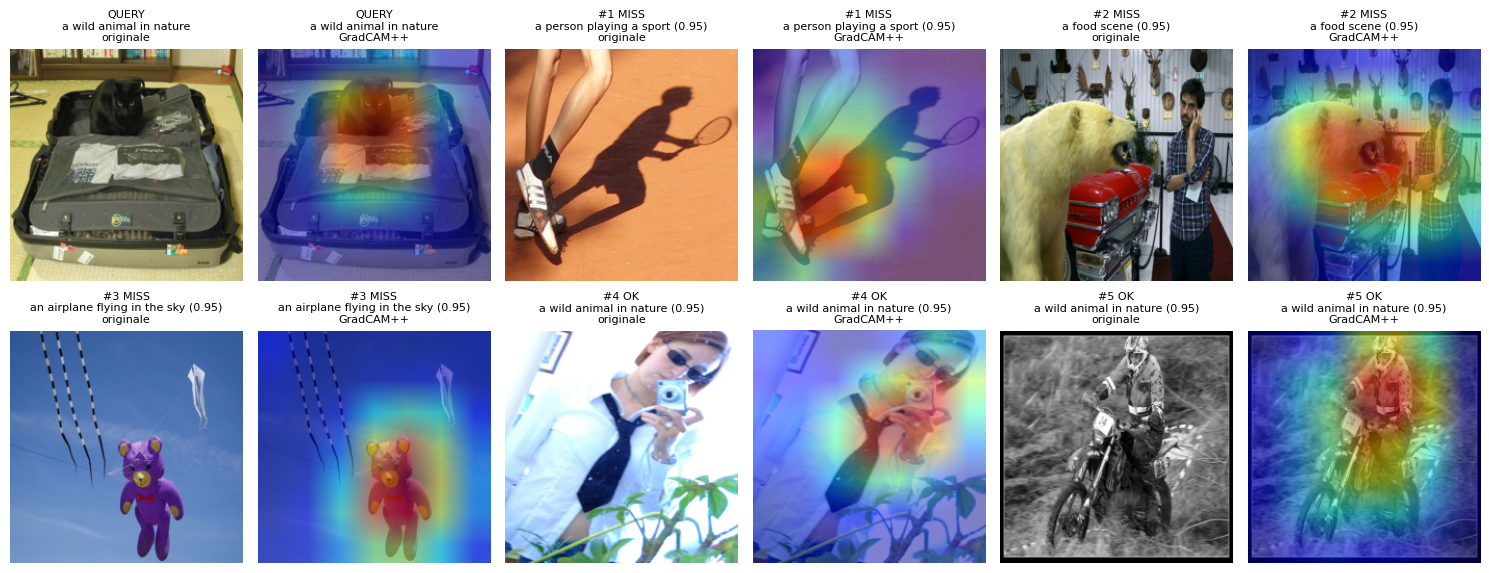

In [19]:
# ============================================================
# 6. ESECUZIONE E VISUALIZZAZIONE GRAD-CAM
# ============================================================
for query_idx in miss_queries:
    # Top-5 elementi restituiti dalla galleria (escludendo l'indice 0 che è la query stessa)
    top5_idx = indices[query_idx][1:6]
    all_idx   = [query_idx] + list(top5_idx)
    
    # Costruisci i percorsi assoluti dei file e le relative label corrette
    all_paths  = [os.path.join(IMAGE_DIR, f"{df_val.iloc[i]['image_id']}.jpg") for i in all_idx]
    all_labels = [int(labels[i]) for i in all_idx]
    
    # Costruisci i titoli per la griglia di plot di Matplotlib
    all_titles = (
        [f"QUERY\n{idx2label.get(int(labels[query_idx]), f'ID: {labels[query_idx]}')}"] +
        [
            f"#{r+1} {'OK' if int(labels[idx]) == int(labels[query_idx]) else 'MISS'}\n"
            f"{idx2label.get(int(labels[idx]), f'ID: {labels[idx]}')} ({scores[query_idx][r+1]:.2f})"
            for r, idx in enumerate(top5_idx)
        ]
    )

    print(f"\n--- Analisi Grad-CAM per la Query errore con Indice: {query_idx} ---")
    
    # Chiamata alla funzione aggiornata che mappa i gradienti sull'embedding del prototipo corretto
    show_gradcam(
        model=model,
        image_paths=all_paths,
        labels=all_labels,         # Fornisce gli ID alla funzione per estrarre prototypes[labels[i]]
        prototypes=prototypes,     # Il dizionario dei prototipi appena calcolato
        target_layer=target_layer,
        titles=all_titles,
        alpha=0.5,
        cols=3
    )